# Проверка качества данных для Символьной Регрессии
В этом ноутбуке мы загружаем сгенерированные батчи данных, смотрим на распределение токенов и визуально оцениваем качество полученных функций.

In [41]:
import gzip
import pickle
import random
from pathlib import Path

import numpy as np
import os
import sys
import matplotlib.pyplot as plt

# Импортируем токенизатор из исходников проекта
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Now you can use a normal absolute import
from src.tokenizer import Tokenizer


# Настроим красивый стиль для графиков
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
def load_data_chunks(data_dir: str, max_chunks: int | None = None):
    """
    Загружает чанки из указанной директории.
    """
    path = Path(data_dir)
    if not path.exists():
        raise FileNotFoundError(f"Директория {data_dir} не найдена!")
        
    chunk_files = list(path.glob("chunk_*.pkl.gz"))
    if not chunk_files:
        raise ValueError("Файлы не найдены!")
        
    # Сортируем по номеру чанка
    chunk_files.sort(key=lambda x: int(x.name.split('_')[1].split('.')[0]))
    
    if max_chunks is not None:
        chunk_files = chunk_files[:max_chunks]
        
    data =[]
    for file in chunk_files:
        with gzip.open(file, "rb") as f:
            chunk_data = pickle.load(f)
            data.extend(chunk_data)
            
    return data

# Загружаем данные из train
DATA_DIR = "../data/train"
# Для проверки возьмем первые 5 чанков (или меньше, если сгенерировано мало)
dataset = load_data_chunks(DATA_DIR, max_chunks=5)

print(f"Успешно загружено примеров: {len(dataset)}")

Успешно загружено примеров: 5000


=== Статистика датасета ===
Средняя длина последовательности токенов: 24.9 (макс: 128)
Среднее число валидных точек на график: 253.5 (мин: 51)


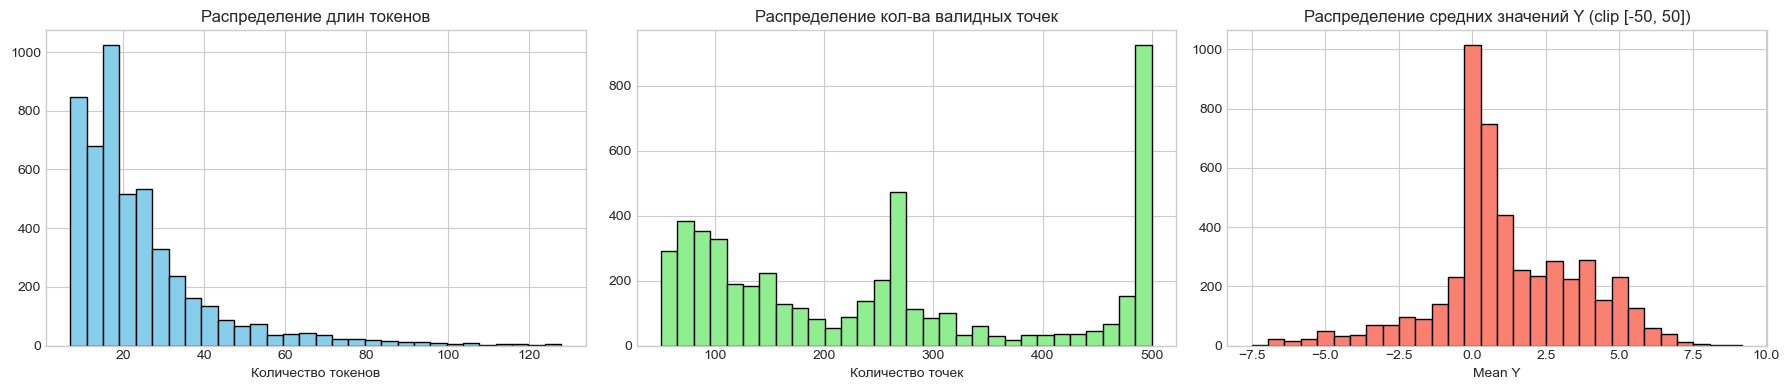

In [43]:
# Собираем статистику
token_lengths = [len(item['tokens']) for item in dataset]
points_counts = [item['points'].shape[0] for item in dataset] # shape (2, N)
y_means =[np.mean(item['points'][:, 1]) for item in dataset]

print("=== Статистика датасета ===")
print(f"Средняя длина последовательности токенов: {np.mean(token_lengths):.1f} (макс: {np.max(token_lengths)})")
print(f"Среднее число валидных точек на график: {np.mean(points_counts):.1f} (мин: {np.min(points_counts)})")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(token_lengths, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Распределение длин токенов')
axes[0].set_xlabel('Количество токенов')

axes[1].hist(points_counts, bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Распределение кол-ва валидных точек')
axes[1].set_xlabel('Количество точек')

axes[2].hist(np.clip(y_means, -50, 50), bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Распределение средних значений Y (clip [-50, 50])')
axes[2].set_xlabel('Mean Y')

plt.tight_layout()
plt.show()

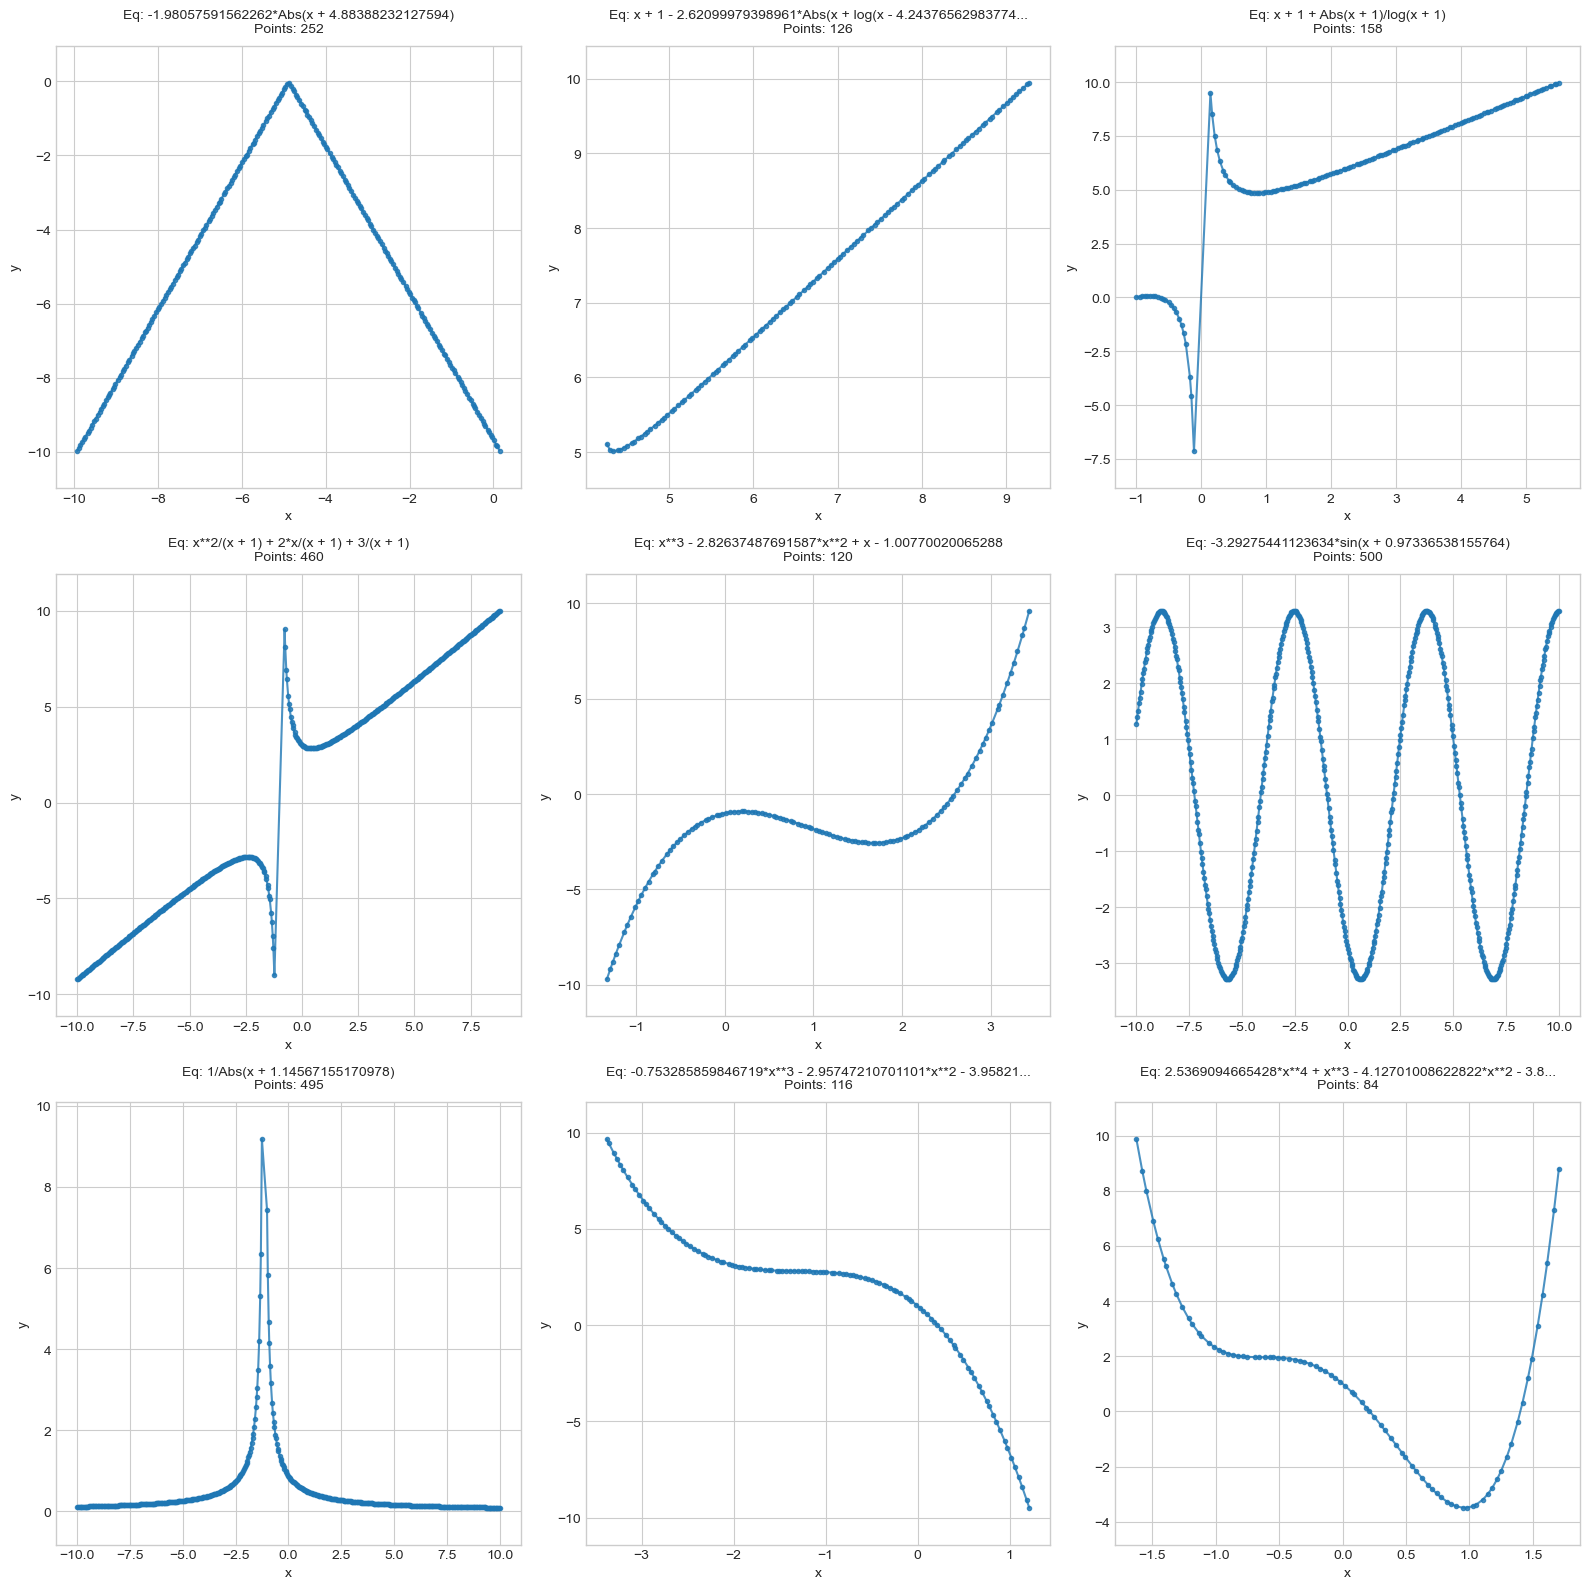

In [44]:
# Выбираем 9 случайных примеров
sample_indices = random.sample(range(len(dataset)), 9)

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    item = dataset[idx]
    
    expr_inst = item['expr_instantiated_str']
    points = item['points']
    
    # points имеет размерность (2, N), где 0-я строка - X, 1-я строка - Y
    x_vals = points[:, 0]
    y_vals = points[:, 1]
    
    # Сортируем точки по X для корректной отрисовки непрерывной линии
    sort_idx = np.argsort(x_vals)
    x_vals = x_vals[sort_idx]
    y_vals = y_vals[sort_idx]
    
    ax = axes[i]
    ax.plot(x_vals, y_vals, marker='o', markersize=3, linestyle='-', linewidth=1.5, alpha=0.8)
    
    # Обрезаем строку формулы, если она слишком длинная
    title_expr = expr_inst if len(expr_inst) <= 60 else expr_inst[:57] + "..."
    ax.set_title(f"Eq: {title_expr}\nPoints: {len(x_vals)}", fontsize=10, pad=10)
    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    # Если данные имеют огромные выбросы, лимитируем Y для наглядности 
    # (генератор уже фильтрует это через max_y/min_y, но перестрахуемся)
    y_min, y_max = np.min(y_vals), np.max(y_vals)
    margin = (y_max - y_min) * 0.1 if y_max != y_min else 1.0
    ax.set_ylim(y_min - margin, y_max + margin)

plt.tight_layout()
plt.show()

In [45]:
# Проверим, что сохраненные токены корректно декодируются обратно в AST
tokenizer = Tokenizer()

sample = random.choice(dataset)
tokens = sample['tokens']

try:
    decoded_expr = tokenizer.token_seq_to_expr(tokens)
    
    print("Успешная детокенизация!\n")
    print("=== Оригинальный скелет (строка) ===")
    print(sample['expr_str'])
    
    print("\n=== Декодированное выражение (SymPy) ===")
    print(decoded_expr)
    
    print("\n=== Выражение с подставленными константами ===")
    print(sample['expr_instantiated_str'])
    
    print("\nТокены:", tokens)

except Exception as e:
    print(f"Ошибка при детокенизации: {e}")

Успешная детокенизация!

=== Оригинальный скелет (строка) ===
C_0 + C_1*x + C_2*x**2 + C_3*x**3

=== Декодированное выражение (SymPy) ===
C*x**3 + (C*x**2 + (C*x + C))

=== Выражение с подставленными константами ===
x**3 + 3.50295175549126*x**2 + x + 3.71702334111242

Токены: [ 1  5  5  5  4  9  4  3  9  4 10  3 21  9  4 10  3 22  2]
